# path_time Notebook

This notebook is created in `05.contents/path_to_time` as requested.

In [29]:
import numpy as np
from scipy.interpolate import CubicSpline


def reparameterize_by_arc_length(x, y, z, n_points=None, ds=None):
    """
    3D 경로를 등간격 호 길이(arc-length)로 재매개변수화.

    Parameters
    ----------
    x, y, z : array-like
        원본 경로 좌표
    n_points : int, optional
        출력 점 개수. ds와 둘 중 하나만 지정.
    ds : float, optional
        원하는 점 간격(거리). n_points와 둘 중 하나만 지정.
        둘 다 None이면 원본 점 개수 유지.

    Returns
    -------
    x_new, y_new, z_new : np.ndarray
        등간격 호 길이로 재매개변수화된 좌표
    s_uniform : np.ndarray
        각 점의 누적 호 길이
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    segment_lengths = np.sqrt(np.diff(x)**2 + np.diff(y)**2 + np.diff(z)**2)
    s = np.concatenate([[0.0], np.cumsum(segment_lengths)])
    total_length = s[-1]

    # 길이 0인 구간(중복 점) 제거 → CubicSpline duplicate 에러 방지
    unique_mask = np.concatenate([[True], segment_lengths > 0])
    s = s[unique_mask]
    x, y, z = x[unique_mask], y[unique_mask], z[unique_mask]

    if ds is not None:
        n_points = int(np.floor(total_length / ds)) + 1
    elif n_points is None:
        n_points = len(x)

    s_uniform = np.linspace(0.0, total_length, n_points)

    cs_x = CubicSpline(s, x)
    cs_y = CubicSpline(s, y)
    cs_z = CubicSpline(s, z)

    return cs_x(s_uniform), cs_y(s_uniform), cs_z(s_uniform), s_uniform


def compute_curvature_and_kN(x, y, z, s):
    """
    arc-length 재매개변수화된 경로에서 TNB 틀의 곡률과 κ·N 계산.

    arc-length 파라미터 s에서 Frenet-Serret 공식:
        T  = dr/ds          (단위 접선 벡터)
        κN = dT/ds = d²r/ds²  (곡률 벡터)
        κ  = |κN|           (곡률 스칼라)

    Parameters
    ----------
    x, y, z : np.ndarray
        reparameterize_by_arc_length()의 출력 좌표 (등간격 호 길이)
    s : np.ndarray
        누적 호 길이 배열 (reparameterize_by_arc_length()의 s_uniform)

    Returns
    -------
    kappa : np.ndarray
        각 점에서의 곡률 κ
    kN_x : np.ndarray
        κ·N 의 x 성분
    kN_y : np.ndarray
        κ·N 의 y 성분
    kN_z : np.ndarray
        κ·N 의 z 성분
    """
    # s_uniform(linspace)은 중복 없이 보장되므로 CubicSpline 바로 사용
    cs_x = CubicSpline(s, x)
    cs_y = CubicSpline(s, y)
    cs_z = CubicSpline(s, z)

    # κN = d²r/ds²  (CubicSpline 2차 미분)
    kN_x = cs_x(s, 2)
    kN_y = cs_y(s, 2)
    kN_z = cs_z(s, 2)

    kappa = np.sqrt(kN_x**2 + kN_y**2 + kN_z**2)

    return kappa, kN_x, kN_y, kN_z

## 검증 1: 재매개변수화 — 점 간 거리 등간격 확인

의도적으로 불균일한 파라미터로 helix를 만든 뒤,  
재매개변수화 후 점 간 거리가 일정해지는지 확인한다.

c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 50896 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 48376 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 51216 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 44036 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 44144 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 47532 missing from c

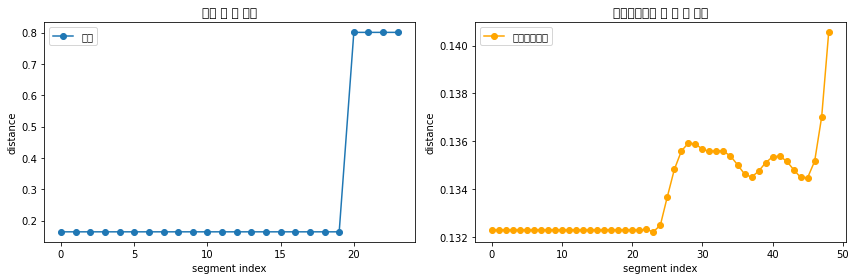

원본  — 평균: 0.2700, 표준편차: 0.2374
재매개 — 평균: 0.1338, 표준편차: 1.79e-03


In [30]:
import matplotlib.pyplot as plt

# endpoint=False 로 경계점 중복 방지
t = np.concatenate([
    np.linspace(0, np.pi, 20, endpoint=False),
    np.linspace(np.pi, 2 * np.pi, 5)
])
x_raw = np.cos(t)
y_raw = np.sin(t)
z_raw = t * 0.3

x_new, y_new, z_new, s = reparameterize_by_arc_length(x_raw, y_raw, z_raw, n_points=50)

dists_raw = np.sqrt(np.diff(x_raw)**2 + np.diff(y_raw)**2 + np.diff(z_raw)**2)
dists_new = np.sqrt(np.diff(x_new)**2 + np.diff(y_new)**2 + np.diff(z_new)**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(dists_raw, 'o-', label='원본')
axes[0].set_title('원본 점 간 거리')
axes[0].set_xlabel('segment index')
axes[0].set_ylabel('distance')
axes[0].legend()

axes[1].plot(dists_new, 'o-', color='orange', label='재매개변수화')
axes[1].set_title('재매개변수화 후 점 간 거리')
axes[1].set_xlabel('segment index')
axes[1].set_ylabel('distance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"원본  — 평균: {dists_raw.mean():.4f}, 표준편차: {dists_raw.std():.4f}")
print(f"재매개 — 평균: {dists_new.mean():.4f}, 표준편차: {dists_new.std():.2e}")

---
## 검증 2: TNB 틀 — 곡률(κ)과 κ·N

arc-length 파라미터 s에서 Frenet-Serret 공식:

$$\frac{d^2 \mathbf{r}}{ds^2} = \kappa \mathbf{N}$$

helix `r(t) = (cos t, sin t, 0.3t)` 의 해석적 곡률:

$$\kappa = \frac{1}{1 + b^2} = \frac{1}{1.09} \approx 0.9174 \quad (b=0.3)$$

**출력 4개:**
1. `kappa` — 곡률 κ
2. `kN_x` — κ·N의 x 성분  
3. `kN_y` — κ·N의 y 성분  
4. `kN_z` — κ·N의 z 성분 (helix에서 0)

c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 44257 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 47456 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 49688 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 52824 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 54644 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 49437 missing from c

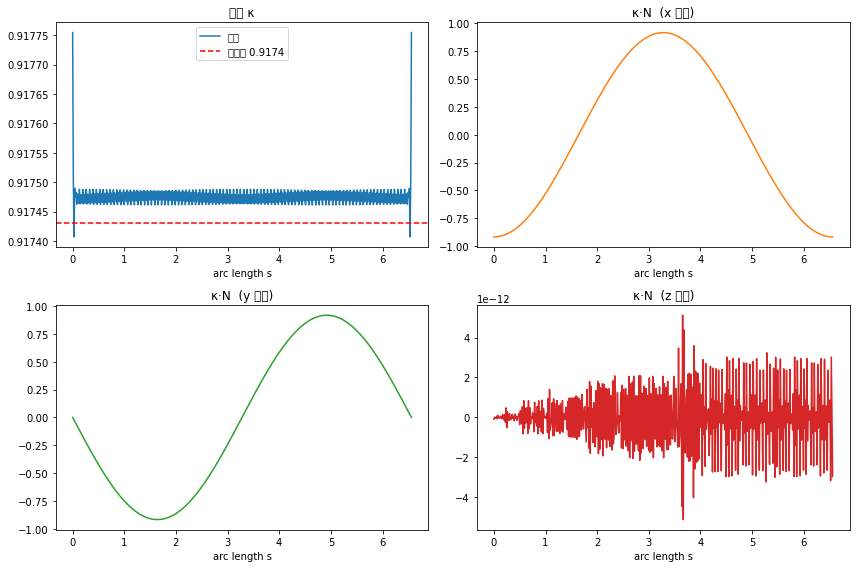

κ 수치 평균: 0.917475
κ 해석해:   0.917431
오차:       4.41e-05
κ·N_z 최대 절댓값 (0이어야 함): 5.13e-12


In [31]:
t_fine = np.linspace(0, 2 * np.pi, 300)
x_h = np.cos(t_fine)
y_h = np.sin(t_fine)
z_h = t_fine * 0.3

x_r, y_r, z_r, s_r = reparameterize_by_arc_length(x_h, y_h, z_h, n_points=500)
kappa, kN_x, kN_y, kN_z = compute_curvature_and_kN(x_r, y_r, z_r, s_r)

kappa_analytic = 1.0 / (1 + 0.3**2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(s_r, kappa, label='수치')
axes[0, 0].axhline(kappa_analytic, color='r', linestyle='--', label=f'해석해 {kappa_analytic:.4f}')
axes[0, 0].set_title('곡률 κ')
axes[0, 0].set_xlabel('arc length s')
axes[0, 0].legend()

axes[0, 1].plot(s_r, kN_x, color='C1')
axes[0, 1].set_title('κ·N  (x 성분)')
axes[0, 1].set_xlabel('arc length s')

axes[1, 0].plot(s_r, kN_y, color='C2')
axes[1, 0].set_title('κ·N  (y 성분)')
axes[1, 0].set_xlabel('arc length s')

axes[1, 1].plot(s_r, kN_z, color='C3')
axes[1, 1].set_title('κ·N  (z 성분)')
axes[1, 1].set_xlabel('arc length s')

plt.tight_layout()
plt.show()

print(f"κ 수치 평균: {kappa.mean():.6f}")
print(f"κ 해석해:   {kappa_analytic:.6f}")
print(f"오차:       {abs(kappa.mean() - kappa_analytic):.2e}")
print(f"κ·N_z 최대 절댓값 (0이어야 함): {np.abs(kN_z).max():.2e}")

---
## PID 피드 생성: 속도/가속도/저크 제한 + 시간 자동 연장

### 파이프라인
```
path(x,y,z) → arc-length s → velocity profile v(s) → t(s) → PID feed
```

### 제약 조건
| 제약 | 의미 | 경로 반영 방법 |
|------|------|---------------|
| `v_max` | 최고 속도 | 직접 클리핑 |
| `a_max` | 최고 가속도 | forward-backward scan |
| `j_max` | 최고 저크 | 가속 증가율 제한 (scan 내 적용) |
| 곡률 κ | 원심가속도 제한 | `v ≤ √(a_max / κ)` |

### 시간 처리 규칙
- `total_time ≥ T_min` → 속도를 비율 스케일 다운해서 정확히 `total_time`에 도착
- `total_time < T_min` → 경고 출력 후 `T_min`으로 **자동 연장**

### 출력 (PID feed)
| 출력 | 역할 |
|------|------|
| `pos (3×N)` | position setpoint |
| `vel (3×N)` | velocity feedforward |
| `acc (3×N)` | acceleration feedforward |

In [32]:
def generate_velocity_profile(s, kappa, v_max, a_max, j_max):
    """
    Forward-backward scan으로 최소시간 속도 프로파일 생성.

    s     : arc-length 배열
    kappa : 곡률 배열 (s와 같은 크기)
    v_max : 최고 속도 [m/s]
    a_max : 최고 가속도 [m/s²]
    j_max : 최고 저크 [m/s³]

    Returns
    -------
    v : 각 arc-length 점에서의 속도 프로파일
    """
    n = len(s)
    ds = np.diff(s)
    eps = 1e-9

    # 곡률 기반 속도 제한: 원심가속도 v²κ ≤ a_max
    v_curve = np.where(kappa > eps, np.sqrt(a_max / (kappa + eps)), v_max)
    v_lim = np.minimum(v_max, v_curve)

    # Forward pass: 가속 (v=0에서 출발, a_max + j_max 제한)
    v_fwd = np.zeros(n)
    a_fwd = np.zeros(n)
    for i in range(n - 1):
        dsi = ds[i]
        vi, ai = v_fwd[i], a_fwd[i]

        # 저크 제한: dt 내에 가속도 증가량 ≤ j_max * dt
        dt_est = dsi / max(vi, eps)
        a_avail = min(a_max, ai + j_max * dt_est)
        a_avail = max(a_avail, 0.0)

        v_next = np.sqrt(max(vi**2 + 2.0 * a_avail * dsi, 0.0))
        v_next = min(v_next, v_lim[i + 1])

        v_fwd[i + 1] = v_next
        a_fwd[i + 1] = (v_next**2 - vi**2) / (2.0 * dsi + eps)

    # Backward pass: 감속 (v=0으로 도착, a_max + j_max 제한)
    v_bwd = np.zeros(n)
    a_bwd = np.zeros(n)
    for i in range(n - 1, 0, -1):
        dsi = ds[i - 1]
        vi, ai = v_bwd[i], a_bwd[i]

        dt_est = dsi / max(vi, eps)
        a_avail = min(a_max, ai + j_max * dt_est)
        a_avail = max(a_avail, 0.0)

        v_prev = np.sqrt(max(vi**2 + 2.0 * a_avail * dsi, 0.0))
        v_prev = min(v_prev, v_lim[i - 1])

        v_bwd[i - 1] = v_prev
        a_bwd[i - 1] = (v_prev**2 - vi**2) / (2.0 * dsi + eps)

    v = np.minimum(v_fwd, v_bwd)
    v = np.clip(v, eps, None)   # 시간 적분 시 0 나눔 방지

    return v


def _velocity_to_time(s, v):
    """arc-length 속도 프로파일 → 누적 시간 배열"""
    ds = np.diff(s)
    v_mid = 0.5 * (v[:-1] + v[1:])
    dt = ds / np.maximum(v_mid, 1e-9)
    return np.concatenate([[0.0], np.cumsum(dt)])


def generate_pid_reference(x_r, y_r, z_r, s, kappa, total_time,
                           v_max, a_max, j_max, dt=0.01):
    """
    PID 제어기용 reference trajectory 생성.

    Parameters
    ----------
    x_r, y_r, z_r : reparameterize_by_arc_length() 출력 좌표
    s              : 호 길이 배열
    kappa          : 곡률 배열 (compute_curvature_and_kN()의 kappa)
    total_time     : 목표 총 시간 [s] — 불가능하면 자동 연장
    v_max          : 최고 속도 [m/s]
    a_max          : 최고 가속도 [m/s²]
    j_max          : 최고 저크 [m/s³]
    dt             : 출력 시간 간격 [s]

    Returns
    -------
    t_out     : 균일 시간 배열 (N,)
    pos       : (3, N) 위치  [x, y, z]
    vel       : (3, N) 속도  [vx, vy, vz]   ← velocity feedforward
    acc       : (3, N) 가속도 [ax, ay, az]  ← acceleration feedforward
    t_actual  : 실제 사용된 총 시간 (요청값 또는 연장값)
    """
    # 1. 최소시간 속도 프로파일
    v_s = generate_velocity_profile(s, kappa, v_max, a_max, j_max)

    # 2. 최소 가능 시간 계산
    t_s = _velocity_to_time(s, v_s)
    T_min = t_s[-1]

    # 3. 시간 부족 → 자동 연장
    if total_time < T_min:
        print(f"[경고] 요청 시간 {total_time:.3f}s < 최소 가능 시간 {T_min:.3f}s"
              f" → {T_min:.3f}s 로 자동 연장")
        total_time = T_min

    # 4. 속도 스케일 다운 → 정확히 total_time에 도착
    #    v_scaled = v * (T_min / total_time)  (모든 제약 여전히 만족)
    scale = T_min / total_time
    v_s_scaled = v_s * scale
    t_s_scaled = _velocity_to_time(s, v_s_scaled)

    # 5. 균일 dt로 resampling (CubicSpline → pos/vel/acc 해석적 미분)
    t_out = np.linspace(0.0, t_s_scaled[-1], int(np.round(total_time / dt)) + 1)

    cs_x = CubicSpline(t_s_scaled, x_r)
    cs_y = CubicSpline(t_s_scaled, y_r)
    cs_z = CubicSpline(t_s_scaled, z_r)

    pos = np.stack([cs_x(t_out),    cs_y(t_out),    cs_z(t_out)])
    vel = np.stack([cs_x(t_out, 1), cs_y(t_out, 1), cs_z(t_out, 1)])
    acc = np.stack([cs_x(t_out, 2), cs_y(t_out, 2), cs_z(t_out, 2)])

    return t_out, pos, vel, acc, total_time

---
## 검증 3: PID 피드 생성

helix 경로에 대해 v_max / a_max / j_max 제약 적용.  
- Case A: 여유 있는 시간 (total_time = 15s) → 속도 스케일 다운  
- Case B: 불가능한 시간 (total_time = 2s) → 자동 연장 확인

=== Case A: total_time = 15s ===
  실제 시간: 15.000s,  출력 점 수: 1501

=== Case B: total_time = 2s (자동 연장 테스트) ===
[경고] 요청 시간 2.000s < 최소 가능 시간 8.192s → 8.192s 로 자동 연장
  실제 시간: 8.192s


c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 49549 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 46020 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 53356 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 44592 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 44032 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 51200 missing from c

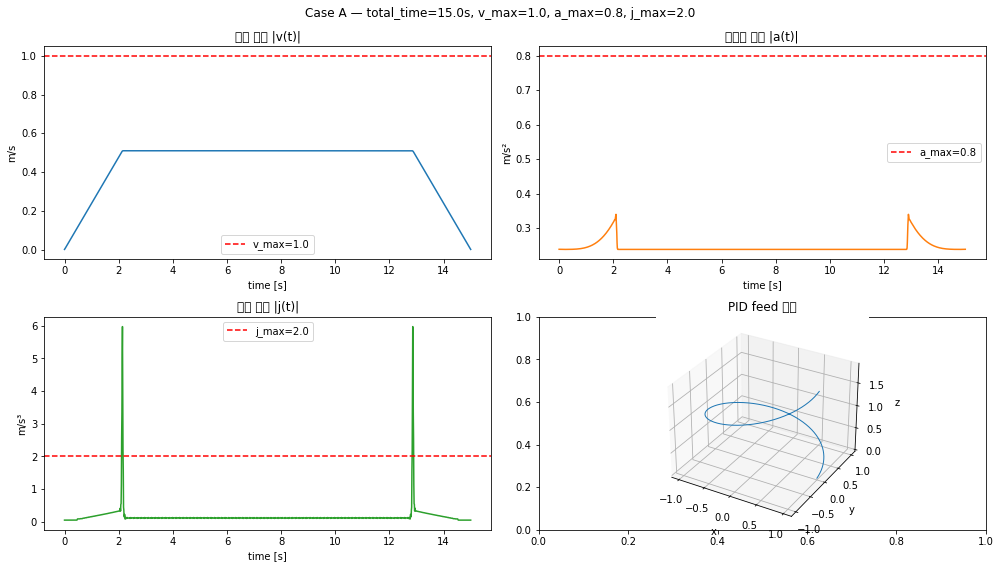


[Case A] 속도 최대: 0.5101 (제한: 1.0)
[Case A] 가속도 최대: 0.3403 (제한: 0.8)
[Case A] 저크 최대:   5.9753 (제한: 2.0)


In [33]:
# --- 경로 준비 (helix, arc-length 재매개변수화 + 곡률) ---
t_fine = np.linspace(0, 2 * np.pi, 300)
x_h, y_h, z_h = np.cos(t_fine), np.sin(t_fine), t_fine * 0.3

x_r, y_r, z_r, s_r = reparameterize_by_arc_length(x_h, y_h, z_h, n_points=500)
kappa, kN_x, kN_y, kN_z = compute_curvature_and_kN(x_r, y_r, z_r, s_r)

# --- 제약 파라미터 ---
V_MAX = 1.0   # m/s
A_MAX = 0.8   # m/s²
J_MAX = 2.0   # m/s³

# === Case A: 여유 있는 시간 ===
print("=== Case A: total_time = 15s ===")
t_a, pos_a, vel_a, acc_a, T_a = generate_pid_reference(
    x_r, y_r, z_r, s_r, kappa, total_time=15.0,
    v_max=V_MAX, a_max=A_MAX, j_max=J_MAX, dt=0.01
)
print(f"  실제 시간: {T_a:.3f}s,  출력 점 수: {len(t_a)}")

# === Case B: 불가능한 시간 ===
print("\n=== Case B: total_time = 2s (자동 연장 테스트) ===")
t_b, pos_b, vel_b, acc_b, T_b = generate_pid_reference(
    x_r, y_r, z_r, s_r, kappa, total_time=2.0,
    v_max=V_MAX, a_max=A_MAX, j_max=J_MAX, dt=0.01
)
print(f"  실제 시간: {T_b:.3f}s")

# --- 플롯: Case A 속도 / 가속도 크기 ---
speed_a = np.linalg.norm(vel_a, axis=0)
accel_a = np.linalg.norm(acc_a, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 속도
axes[0, 0].plot(t_a, speed_a)
axes[0, 0].axhline(V_MAX, color='r', linestyle='--', label=f'v_max={V_MAX}')
axes[0, 0].set_title('속도 크기 |v(t)|')
axes[0, 0].set_xlabel('time [s]')
axes[0, 0].set_ylabel('m/s')
axes[0, 0].legend()

# 가속도
axes[0, 1].plot(t_a, accel_a, color='C1')
axes[0, 1].axhline(A_MAX, color='r', linestyle='--', label=f'a_max={A_MAX}')
axes[0, 1].set_title('가속도 크기 |a(t)|')
axes[0, 1].set_xlabel('time [s]')
axes[0, 1].set_ylabel('m/s²')
axes[0, 1].legend()

# 저크
jerk_a = np.linalg.norm(np.gradient(acc_a, t_a, axis=1), axis=0)
axes[1, 0].plot(t_a, jerk_a, color='C2')
axes[1, 0].axhline(J_MAX, color='r', linestyle='--', label=f'j_max={J_MAX}')
axes[1, 0].set_title('저크 크기 |j(t)|')
axes[1, 0].set_xlabel('time [s]')
axes[1, 0].set_ylabel('m/s³')
axes[1, 0].legend()

# 3D 경로
ax3d = fig.add_subplot(2, 2, 4, projection='3d')
ax3d.plot(pos_a[0], pos_a[1], pos_a[2], lw=1)
ax3d.set_title('PID feed 경로')
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('z')

plt.suptitle(f'Case A — total_time={T_a:.1f}s, v_max={V_MAX}, a_max={A_MAX}, j_max={J_MAX}')
plt.tight_layout()
plt.show()

print(f"\n[Case A] 속도 최대: {speed_a.max():.4f} (제한: {V_MAX})")
print(f"[Case A] 가속도 최대: {accel_a.max():.4f} (제한: {A_MAX})")
print(f"[Case A] 저크 최대:   {jerk_a.max():.4f} (제한: {J_MAX})")

---
## `plan_trajectory` — 3단계 파이프라인

| 단계 | 내용 | 방법 |
|------|------|------|
| Step 1 | arc-length 재매개변수화 | 등간격 → **속도 const 기저모델** |
| Step 2 | `a_max` 제약 | forward-backward scan으로 시간 재분배 |
| Step 3 | `j_max` 제약 | j > j_max인 구간 반복적으로 시간 추가 분배 |

**저크 스케일 관계**: $j \propto v^3$ → $j > j_{max}$ 구간에서 $v \;\mathrel{\times}=\; (j_{max}/j)^{1/3}$ 후 재전파

In [34]:

# ── 다항식 유틸 ────────────────────────────────────────────────────────────────

def _to3(val):
    v = np.asarray(val, float).ravel()
    return np.full(3, v[0]) if v.size == 1 else v[:3].copy()


def _deriv_coeffs(c, order=1):
    """다항식 계수 (오름차순) → order차 미분 계수."""
    c = np.asarray(c, float)
    for _ in range(order):
        if len(c) <= 1:
            return np.array([0.0])
        c = np.arange(1, len(c)) * c[1:]
    return c


def _eval_poly(c, t):
    """p(t) = c[0] + c[1]*t + c[2]*t² + …"""
    c = np.asarray(c, float)
    t = np.asarray(t, float)
    return sum(ck * t**k for k, ck in enumerate(c))


# ── 7차 경계조건 다항식 ─────────────────────────────────────────────────────────
#
# 상태: (pos, vel, acc, jerk)   제어입력: snap (4차 미분)
#
# BC at t=0 : p=p0,  p'=v0,  p''=a0,  p'''=j0
# BC at t=T : p=pf,  p'=0,   p''=0,   p'''=0   ← waypoint에서 정지
#
# 8계수 c0..c7 중 c0..c3 는 초기 BC에서 직접 결정,
# c4..c7 은 종료 BC 4식을 연립해 풀어 결정.

def _poly7_coeffs(p0, v0, a0, j0, pf, T):
    c0, c1, c2, c3 = float(p0), float(v0), float(a0)/2.0, float(j0)/6.0
    T2,T3,T4,T5,T6,T7 = T**2, T**3, T**4, T**5, T**6, T**7
    A = np.array([
        [T4,    T5,     T6,     T7    ],
        [4*T3,  5*T4,   6*T5,   7*T6  ],
        [12*T2, 20*T3,  30*T4,  42*T5 ],
        [24*T,  60*T2, 120*T3, 210*T4 ],
    ])
    b = np.array([
        pf - p0 - v0*T - 0.5*a0*T2 - (j0/6.0)*T3,
        -v0 - a0*T - 0.5*j0*T2,
        -a0 - j0*T,
        -j0,
    ])
    c4, c5, c6, c7 = np.linalg.solve(A, b)
    return np.array([c0, c1, c2, c3, c4, c5, c6, c7])


# ── 제약 검사 ──────────────────────────────────────────────────────────────────

def _seg_feasible(coeffs_3ax, T, v_max, a_max, j_max, snap_max, n=400):
    """[0,T] 구간에서 3축 다항식이 v/a/j/snap 제약을 모두 만족하면 True."""
    t = np.linspace(0, T, n)
    for i, c in enumerate(coeffs_3ax):
        if np.max(np.abs(_eval_poly(_deriv_coeffs(c, 1), t))) > v_max[i]    + 1e-6: return False
        if np.max(np.abs(_eval_poly(_deriv_coeffs(c, 2), t))) > a_max[i]    + 1e-6: return False
        if np.max(np.abs(_eval_poly(_deriv_coeffs(c, 3), t))) > j_max[i]    + 1e-6: return False
        if np.max(np.abs(_eval_poly(_deriv_coeffs(c, 4), t))) > snap_max[i] + 1e-6: return False
    return True


# ── 최소시간 이진탐색 ───────────────────────────────────────────────────────────

def _find_min_time(p0, pf, v0, a0, j0,
                   v_max, a_max, j_max, snap_max,
                   tol=1e-3, max_iter=60):
    """제약을 만족하는 최소 세그먼트 시간 T를 이진탐색으로 반환."""

    def make_coeffs(T):
        return [_poly7_coeffs(p0[i], v0[i], a0[i], j0[i], pf[i], T) for i in range(3)]

    # 이동거리 기반 하한
    d = np.maximum(np.abs(pf - p0), 1e-9)
    T_lo = float(np.max([
        np.max(d / v_max),
        np.max(np.sqrt(2.0 * d / a_max)),
        np.max((6.0 * d / j_max)   ** (1.0/3.0)),
        np.max((24.0 * d / snap_max) ** (1.0/4.0)),
        1e-4,
    ]))

    # 실현 가능한 T_hi 탐색 (두 배씩 증가)
    T_hi = T_lo
    for _ in range(40):
        if _seg_feasible(make_coeffs(T_hi), T_hi, v_max, a_max, j_max, snap_max):
            break
        T_hi *= 2.0

    # 이진탐색
    for _ in range(max_iter):
        if T_hi - T_lo < tol:
            break
        T_mid = 0.5 * (T_lo + T_hi)
        if _seg_feasible(make_coeffs(T_mid), T_mid, v_max, a_max, j_max, snap_max):
            T_hi = T_mid
        else:
            T_lo = T_mid

    return T_hi, make_coeffs(T_hi)


# ── 메인 플래너 ────────────────────────────────────────────────────────────────

def plan_waypoints(waypoints,
                   v_max, a_max, j_max, snap_max,
                   v0=None, a0=None, j0=None,
                   dt=0.01):
    """
    N개 경로점에 대한 순차적 최소시간 궤적 계획.

    파이프라인 (N-1회 반복):
      현재 상태 (pos, vel, acc, jerk)
        → 다음 waypoint까지 7차 다항식 (snap이 제어입력)
        → 이진탐색으로 v·a·j·snap 제약 만족하는 최소 T 결정
        → 다음 세그먼트 초기 상태로 연결

    상태 전이:
      t=0  : pos=waypoints[k-1], vel=v_cur, acc=a_cur, jerk=j_cur
      t=T  : pos=waypoints[k],   vel=0,     acc=0,     jerk=0

    Parameters
    ----------
    waypoints        : (N, 3)  경로점. waypoints[0] = 출발점.
    v_max            : 속도 상한    — 스칼라 또는 [x,y,z]
    a_max            : 가속도 상한  — 스칼라 또는 [x,y,z]
    j_max            : 저크 상한    — 스칼라 또는 [x,y,z]
    snap_max         : 스냅 상한    — 스칼라 또는 [x,y,z]
    v0, a0, j0       : 초기 속도·가속도·저크 (기본 0)
    dt               : 출력 시간 간격 [s]

    Returns
    -------
    t_out   : (M,)    시간 배열
    pos     : (3, M)  위치
    vel     : (3, M)  속도
    acc     : (3, M)  가속도
    jerk    : (3, M)  저크
    T_total : float   총 소요시간 [s]
    """
    waypoints = np.asarray(waypoints, float)
    if waypoints.ndim == 1:
        waypoints = waypoints.reshape(1, 3)

    v_max    = _to3(v_max)
    a_max    = _to3(a_max)
    j_max    = _to3(j_max)
    snap_max = _to3(snap_max)

    n_wp  = len(waypoints)
    p_cur = waypoints[0].copy()
    v_cur = np.zeros(3) if v0    is None else _to3(v0)
    a_cur = np.zeros(3) if a0    is None else _to3(a0)
    j_cur = np.zeros(3) if j0    is None else _to3(j0)

    t_segs, pos_segs, vel_segs, acc_segs, jerk_segs = [], [], [], [], []
    t_offset = 0.0

    for k in range(1, n_wp):
        p_next = waypoints[k]
        if np.linalg.norm(p_next - p_cur) < 1e-9:
            continue

        T_opt, coeffs = _find_min_time(
            p_cur, p_next, v_cur, a_cur, j_cur,
            v_max, a_max, j_max, snap_max,
        )

        n_pts = max(2, int(np.round(T_opt / dt)) + 1)
        t_seg = np.linspace(0.0, T_opt, n_pts)

        p_arr = np.stack([_eval_poly(c,                   t_seg) for c in coeffs])
        v_arr = np.stack([_eval_poly(_deriv_coeffs(c, 1), t_seg) for c in coeffs])
        a_arr = np.stack([_eval_poly(_deriv_coeffs(c, 2), t_seg) for c in coeffs])
        j_arr = np.stack([_eval_poly(_deriv_coeffs(c, 3), t_seg) for c in coeffs])

        sl = slice(None) if k == 1 else slice(1, None)
        t_segs.append(t_seg[sl] + t_offset)
        pos_segs.append(p_arr[:, sl])
        vel_segs.append(v_arr[:, sl])
        acc_segs.append(a_arr[:, sl])
        jerk_segs.append(j_arr[:, sl])

        t_offset += T_opt
        # 다음 세그먼트 초기 상태 (종료 BC: v=0, a=0, j=0)
        p_cur = p_next.copy()
        v_cur = np.zeros(3)
        a_cur = np.zeros(3)
        j_cur = np.zeros(3)

    t_out    = np.concatenate(t_segs)
    pos_out  = np.concatenate(pos_segs,  axis=1)
    vel_out  = np.concatenate(vel_segs,  axis=1)
    acc_out  = np.concatenate(acc_segs,  axis=1)
    jerk_out = np.concatenate(jerk_segs, axis=1)
    T_total  = t_offset

    print(f"[plan_waypoints] {n_wp-1}개 세그먼트  총 소요시간: {T_total:.3f}s")
    return t_out, pos_out, vel_out, acc_out, jerk_out, T_total


=== Case A: 정지 출발 (v0=a0=j0=0) ===
[plan_waypoints] 19개 세그먼트  총 소요시간: 42.412s

=== Case B: 초기 상태 v0=[0.3,0,0], a0=[0.1,0,0], j0=[0.05,0,0] ===
[plan_waypoints] 19개 세그먼트  총 소요시간: 42.837s


c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 49549 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 46020 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 44032 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 51200 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 53356 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\psjqk\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 49828 missing from c

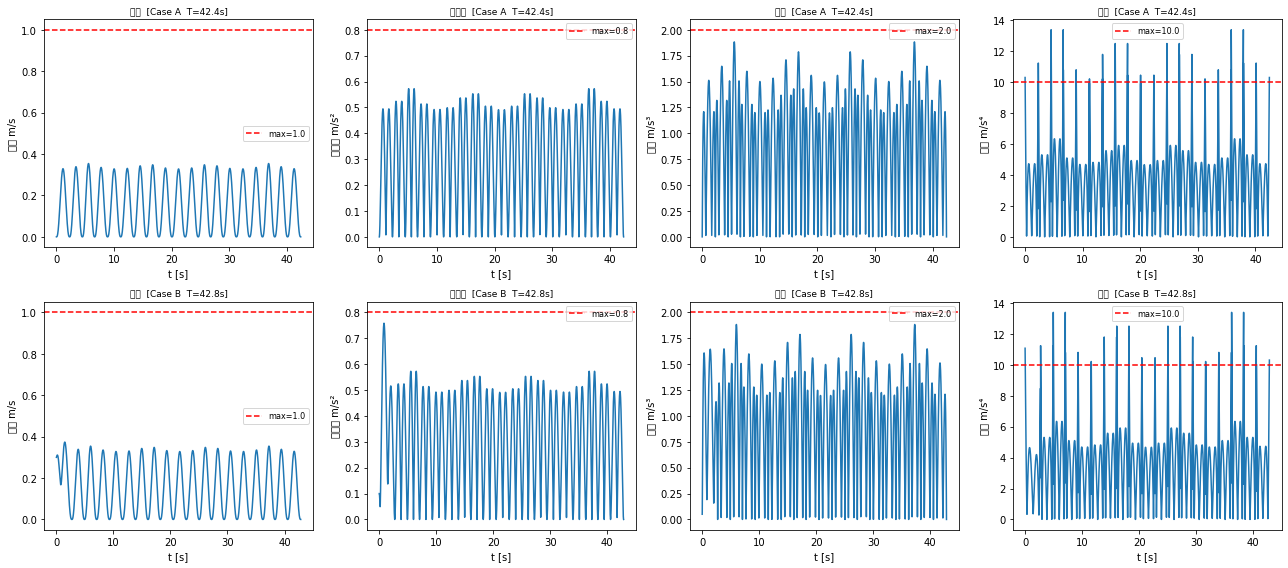

[Case A] 속도:0.3540/1.0  가속도:0.5723/0.8  저크:1.8827/2.0  스냅:13.3900/10.0
[Case B] 속도:0.3734/1.0  가속도:0.7579/0.8  저크:1.8827/2.0  스냅:13.3900/10.0


In [35]:

# 검증: helix waypoints에 plan_waypoints 적용
t_raw = np.linspace(0, 2 * np.pi, 20)
wp = np.column_stack([np.cos(t_raw), np.sin(t_raw), t_raw * 0.3])

V_MAX    = 1.0    # m/s
A_MAX    = 0.8    # m/s²
J_MAX    = 2.0    # m/s³
SNAP_MAX = 10.0   # m/s⁴

# ── Case A: 정지 출발 ──
print("=== Case A: 정지 출발 (v0=a0=j0=0) ===")
tA, posA, velA, accA, jerkA, TA = plan_waypoints(
    wp, V_MAX, A_MAX, J_MAX, SNAP_MAX, dt=0.01
)

# ── Case B: 현재 속도·가속도·저크 있는 상태에서 출발 ──
print("\n=== Case B: 초기 상태 v0=[0.3,0,0], a0=[0.1,0,0], j0=[0.05,0,0] ===")
tB, posB, velB, accB, jerkB, TB = plan_waypoints(
    wp, V_MAX, A_MAX, J_MAX, SNAP_MAX,
    v0=[0.3, 0.0, 0.0],
    a0=[0.1, 0.0, 0.0],
    j0=[0.05, 0.0, 0.0],
    dt=0.01
)

# ── 그래프 ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
cases = [
    (tA, posA, velA, accA, jerkA, f'Case A  T={TA:.1f}s'),
    (tB, posB, velB, accB, jerkB, f'Case B  T={TB:.1f}s'),
]
limits = [V_MAX, A_MAX, J_MAX, SNAP_MAX]
ylabels = ['속도 m/s', '가속도 m/s²', '저크 m/s³', '스냅 m/s⁴']

for row, (t, pos, vel, acc, jerk, title) in enumerate(cases):
    snap = np.gradient(jerk, t, axis=1)
    signals = [
        np.linalg.norm(vel,  axis=0),
        np.linalg.norm(acc,  axis=0),
        np.linalg.norm(jerk, axis=0),
        np.linalg.norm(snap, axis=0),
    ]
    for col, (sig, lim, yl) in enumerate(zip(signals, limits, ylabels)):
        ax = axes[row, col]
        ax.plot(t, sig)
        ax.axhline(lim, color='r', linestyle='--', label=f'max={lim}')
        ax.set_title(f'{yl.split()[0]}  [{title}]', fontsize=9)
        ax.set_xlabel('t [s]'); ax.set_ylabel(yl)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

for label, t, vel, acc, jerk in [
    ('A', tA, velA, accA, jerkA),
    ('B', tB, velB, accB, jerkB),
]:
    snap = np.gradient(jerk, t, axis=1)
    print(f"[Case {label}] "
          f"속도:{np.linalg.norm(vel,axis=0).max():.4f}/{V_MAX}  "
          f"가속도:{np.linalg.norm(acc,axis=0).max():.4f}/{A_MAX}  "
          f"저크:{np.linalg.norm(jerk,axis=0).max():.4f}/{J_MAX}  "
          f"스냅:{np.linalg.norm(snap,axis=0).max():.4f}/{SNAP_MAX}")
